## Lab 5 : Knowledge reasoning with rule and Knowledge Graph Embedding (KGE)

### Part 1 : Knowledge reasoning with SWRL

In [2]:
#pip install owlready2

In [27]:
from owlready2 import get_ontology, World
from pathlib import Path
from rdflib import Graph, Namespace, RDF

ONTO_PATH = Path(r"C:\Users\sagro\project_web\data\family.owl")
NS = "http://www.owl-ontologies.com/unnamed.owl#"
FAM = Namespace(NS)

# 1 et 2 : Load ontology and parse individuals
world = World()
onto  = world.get_ontology("http://www.owl-ontologies.com/unnamed.owl")
with open(ONTO_PATH, "rb") as f:
    onto.load(fileobj=f)

g = Graph()
g.parse(str(ONTO_PATH))

print("[2] Ontology structure inspection:")
print(f"    Classes     : {[c.name for c in onto.classes()]}")
print(f"    Properties  : {[p.name for p in onto.properties()]}")

individuals_data = []
for subj in g.subjects(RDF.type, None):
    name = str(subj).replace(NS, "")
    if not name or name.startswith("http"):
        continue
    age_val = g.value(subj, FAM.age)
    if age_val is not None:
        individuals_data.append((name, int(age_val)))

print(f"    Individuals : {[n for n, a in individuals_data]}")
print("\n    Individual ages:")
for name, age in individuals_data:
    print(f"      {name:12s} → age = {age}")

# 3 : Create oldPerson class 
with onto:
    class oldPerson(onto.Person):
        """Person whose age > 60 — inferred by SWRL rule."""
        pass

print("\n[3] Class 'oldPerson' created as subclass of Person")

# 4 : Define SWRL rule 
SWRL_RULE = "Person(?p) ∧ age(?p, ?a) ∧ swrlb:greaterThan(?a, 60) → oldPerson(?p)"
print(f"\n[4] SWRL rule defined:")
print(f"    {SWRL_RULE}")
print(f"    Formal notation:")
print(f"      Person(?p) ∧ age(?p, ?a) ∧ swrlb:greaterThan(?a, 60) → oldPerson(?p)")

# 5 : Apply rule 
print("\n[5] Applying rule (Python fallback):")
old_persons = [(name, age) for name, age in individuals_data if age > 60]
for name, age in old_persons:
    print(f"    [INFERRED] {name} (age={age}) → oldPerson")

# 6 : Results 
print(f"\n[6] Reasoning results (engine: Python fallback):")
print(f"\n    Rule applied:")
print(f"      {SWRL_RULE}")
print(f"\n    Inferred instances of oldPerson:")
for name, age in old_persons:
    print(f"      ✓ {name:12s} (age = {age})")
print(f"\n    Total inferred: {len(old_persons)} individual(s)")

# 7 : Summary table 
print("\n[7] Full population summary:")
print(f"    {'Name':12s} {'Age':>5s}  {'oldPerson?':>12s}")
print("    " + "-" * 32)
for name, age in individuals_data:
    flag = "✓ YES" if age > 60 else "  no"
    print(f"    {name:12s} {age:>5d}  {flag:>12s}")

print("\n" + "=" * 55)
print("  Expected: Peter (70) and Marie (69) → oldPerson")
print("=" * 55)

[2] Ontology structure inspection:
    Classes     : ['Son', 'Child', 'Daughter', 'Person', 'Uncle', 'Parent', 'Male', 'Grandmother', 'Grandparents', 'Female', 'Grandfather', 'Father', 'Mother', 'Sibling', 'Brother', 'Sister']
    Properties  : ['age', 'nationality', 'name', 'isSonOf', 'isBrotherOf', 'isMotherOf', 'isFatherOf', 'isDaughterOf', 'isSisterOf', 'isSiblingOf', 'isChildOf', 'isParentOf', 'isMarriedWith']
    Individuals : ['Tom', 'Thomas', 'Michael', 'Peter', 'John', 'Pedro', 'Paul', 'Alex', 'Marie', 'Sylvie', 'Claude', 'Chloé']

    Individual ages:
      Tom          → age = 10
      Thomas       → age = 40
      Michael      → age = 5
      Peter        → age = 70
      John         → age = 45
      Pedro        → age = 10
      Paul         → age = 38
      Alex         → age = 25
      Marie        → age = 69
      Sylvie       → age = 30
      Claude       → age = 5
      Chloé        → age = 18

[3] Class 'oldPerson' created as subclass of Person

[4] SWRL rule define

### Part 2 : Knowledge Graph Embedding

#### Data preparation

In [28]:
import random
import shutil
from collections import defaultdict, Counter
from pathlib import Path

In [29]:
KGE_DIR = Path("output/kge")
SUBSET_DIR  = KGE_DIR / "subsets"
SUBSET_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
SUBSET_SIZES = [20_000, 50_000]  

In [30]:
#1. Validate the existing splits

def load_split(path: Path) -> list[tuple[int, int, int]]:
    """Load a KGE split file."""
    triples = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 3:
                triples.append((int(parts[0]), int(parts[1]), int(parts[2])))
    return triples


def validate_splits(train, valid, test):
    """
    Verify data integrity:
    - No triple appears in both train and test/valid
    - All entities in valid/test appear at least once in train
    """
    print("\n[Validation] Checking split integrity...")

    train_set  = set(train)
    valid_set  = set(valid)
    test_set   = set(test)

    # Check for leakage
    train_valid_overlap = train_set & valid_set
    train_test_overlap  = train_set & test_set
    print(f"  Train/valid overlap : {len(train_valid_overlap)} triples (should be 0)")
    print(f"  Train/test overlap  : {len(train_test_overlap)} triples (should be 0)")

    # Check entity coverage
    train_entities = set()
    for h, r, t in train:
        train_entities.add(h)
        train_entities.add(t)

    unseen_valid = set()
    for h, r, t in valid:
        if h not in train_entities: unseen_valid.add(h)
        if t not in train_entities: unseen_valid.add(t)

    unseen_test = set()
    for h, r, t in test:
        if h not in train_entities: unseen_test.add(h)
        if t not in train_entities: unseen_test.add(t)

    print(f"  Unseen entities in valid : {len(unseen_valid)}")
    print(f"  Unseen entities in test  : {len(unseen_test)}")

    if len(train_valid_overlap) == 0 and len(train_test_overlap) == 0:
        print("  ✓ No leakage detected")
    else:
        print("  ⚠️  Leakage detected — check split generation")

    return len(unseen_valid) == 0 and len(unseen_test) == 0


In [32]:
# 2. Print statistics on existing splits

def print_split_stats(train, valid, test):
    total = len(train) + len(valid) + len(test)
    all_triples = train + valid + test

    entities  = set()
    relations = set()
    for h, r, t in all_triples:
        entities.add(h); entities.add(t); relations.add(r)

    rel_counts = Counter(r for _, r, _ in train)

    print("\n[Statistics] Existing split summary:")
    print(f"  {'Split':12s} {'Triples':>10s} {'%':>6s}")
    print("  " + "-" * 32)
    print(f"  {'Train':12s} {len(train):>10,} {len(train)/total*100:>5.1f}%")
    print(f"  {'Validation':12s} {len(valid):>10,} {len(valid)/total*100:>5.1f}%")
    print(f"  {'Test':12s} {len(test):>10,} {len(test)/total*100:>5.1f}%")
    print(f"  {'TOTAL':12s} {total:>10,}")
    print(f"\n  Unique entities  : {len(entities):,}")
    print(f"  Unique relations : {len(relations)}")
    print(f"\n  Top 5 relations by frequency (train):")
    for rel_id, count in rel_counts.most_common(5):
        print(f"    Relation {rel_id:3d} : {count:>8,} triples")

In [33]:
# 3. Build size-sensitivity subsets

def build_subset(all_triples: list, target_size: int, seed: int = 42) -> tuple:
    """
    Sample a stratified subset of `target_size` triples from all_triples,
    then split 80/10/10 ensuring entity coverage.

    Stratified by relation to maintain relation distribution.
    """
    rng = random.Random(seed)

    if target_size >= len(all_triples):
        return None   # Use full dataset

    # Group by relation
    by_relation = defaultdict(list)
    for t in all_triples:
        by_relation[t[1]].append(t)

    # Sample proportionally per relation
    sampled = []
    for rel, triples in by_relation.items():
        n = max(1, int(len(triples) / len(all_triples) * target_size))
        rng.shuffle(triples)
        sampled.extend(triples[:n])

    # Top up if needed
    remaining = [t for t in all_triples if t not in set(sampled)]
    rng.shuffle(remaining)
    sampled.extend(remaining[:target_size - len(sampled)])
    sampled = sampled[:target_size]
    rng.shuffle(sampled)

    # 80/10/10 split
    n       = len(sampled)
    n_train = int(n * 0.80)
    n_valid = int(n * 0.10)

    # Ensure all entities in valid/test appear in train
    train_set = set(sampled[:n_train])
    train_entities = set()
    for h, r, t in train_set:
        train_entities.add(h); train_entities.add(t)

    valid_raw = sampled[n_train:n_train + n_valid]
    test_raw  = sampled[n_train + n_valid:]

    # Move unseen-entity triples back to train
    valid_clean, test_clean = [], []
    overflow = []

    for h, r, t in valid_raw:
        if h in train_entities and t in train_entities:
            valid_clean.append((h, r, t))
        else:
            overflow.append((h, r, t))

    for h, r, t in test_raw:
        if h in train_entities and t in train_entities:
            test_clean.append((h, r, t))
        else:
            overflow.append((h, r, t))

    train_final = list(train_set) + overflow

    return train_final, valid_clean, test_clean


def write_split(path: Path, triples: list):
    """Write a split file in TSV format (head_id TAB rel_id TAB tail_id)."""
    with open(path, "w", encoding="utf-8") as f:
        for h, r, t in triples:
            f.write(f"{h}\t{r}\t{t}\n")

In [34]:
#Main

def run_data_preparation():
    print("=" * 55)
    print("  PART 2 — KGE Data Preparation")
    print("=" * 55)

    # Load existing splits from Lab 2
    print("\n[1] Loading existing splits from Lab 2 (output/kge/)...")
    train_path = KGE_DIR / "train.txt"
    valid_path = KGE_DIR / "valid.txt"
    test_path  = KGE_DIR / "test.txt"

    if not train_path.exists():
        print("  [ERROR] output/kge/train.txt not found.")
        print("  Please run Lab 2 Step 5 first (step5_clean_and_prepare_kge.py)")
        return

    train = load_split(train_path)
    valid = load_split(valid_path)
    test  = load_split(test_path)
    print(f"  ✓ Train: {len(train):,} | Valid: {len(valid):,} | Test: {len(test):,}")

    # Validate
    validate_splits(train, valid, test)
    print_split_stats(train, valid, test)

    # Copy full split to subsets/
    print("\n[2] Copying full split to subsets/...")
    for fname in ["train.txt", "valid.txt", "test.txt"]:
        src = KGE_DIR / fname
        dst = SUBSET_DIR / fname.replace(".txt", "_full.txt")
        shutil.copy(src, dst)
    print(f"  ✓ Full split saved in {SUBSET_DIR}/")

    # Build sub-sampled versions
    all_triples = train + valid + test
    print(f"\n[3] Building size-sensitivity subsets from {len(all_triples):,} total triples...")

    for target in SUBSET_SIZES:
        result = build_subset(all_triples, target, seed=RANDOM_SEED)
        if result is None:
            print(f"  [{target//1000}k] Skipped (target >= full dataset size)")
            continue

        sub_train, sub_valid, sub_test = result
        total_sub = len(sub_train) + len(sub_valid) + len(sub_test)

        tag = f"{target//1000}k"
        write_split(SUBSET_DIR / f"train_{tag}.txt", sub_train)
        write_split(SUBSET_DIR / f"valid_{tag}.txt", sub_valid)
        write_split(SUBSET_DIR / f"test_{tag}.txt",  sub_test)

        print(f"  [{tag}] Train={len(sub_train):,} Valid={len(sub_valid):,} "
              f"Test={len(sub_test):,} → Total={total_sub:,}")

    print(f"\n✓ All subsets saved in {SUBSET_DIR}/")
    print("\n  Files generated:")
    for f in sorted(SUBSET_DIR.iterdir()):
        print(f"    {f.name:30s}  ({f.stat().st_size:>10,} bytes)")


if __name__ == "__main__":
    run_data_preparation()


  PART 2 — KGE Data Preparation

[1] Loading existing splits from Lab 2 (output/kge/)...
  ✓ Train: 50,138 | Valid: 6,260 | Test: 6,287

[Validation] Checking split integrity...
  Train/valid overlap : 0 triples (should be 0)
  Train/test overlap  : 0 triples (should be 0)
  Unseen entities in valid : 4061
  Unseen entities in test  : 4067
  ✓ No leakage detected

[Statistics] Existing split summary:
  Split           Triples      %
  --------------------------------
  Train            50,138  80.0%
  Validation        6,260  10.0%
  Test              6,287  10.0%
  TOTAL            62,685

  Unique entities  : 50,218
  Unique relations : 24

  Top 5 relations by frequency (train):
    Relation   4 :   13,782 triples
    Relation  21 :    9,344 triples
    Relation   8 :    8,637 triples
    Relation   9 :    5,244 triples
    Relation  20 :    3,537 triples

[2] Copying full split to subsets/...
  ✓ Full split saved in output\kge\subsets/

[3] Building size-sensitivity subsets from 62

#### Embedding models, Training Configuration, Evaluation Task: Link Prediction,Experiments to Conduct

In [1]:
import json
import csv
import time
from pathlib import Path

import torch
from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory

In [2]:
KGE_DIR = Path("output/kge")
RESULTS_DIR = KGE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Fair hyperparameter configuration 
HPARAMS = {
    "embedding_dim":   128,    
    "learning_rate":   0.001,  
    "batch_size":      512,    
    "num_epochs":      100,    
    "num_negs_per_pos": 64,    
    "random_seed":     42,
}

# Models to train
MODELS = ["TransE", "ComplEx"]

# Size sensitivity experiments
SENSITIVITY_SIZES = ["20k", "50k", "full"]

In [16]:
import numpy as np
from pykeen.triples import TriplesFactory

def read_triples(path):
    triples = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 3:
                triples.append(parts)
    return np.array(triples, dtype=str)


def load_triples_factory(train_path, valid_path, test_path):
    train_np = read_triples(train_path)
    valid_np = read_triples(valid_path)
    test_np  = read_triples(test_path)

    print(f"    Train : {train_np.shape[0]:>8,} triples (before filtering)")

    # Build train factory first
    tf_train = TriplesFactory.from_labeled_triples(
        triples=train_np,
        create_inverse_triples=False,
    )

    # Filter valid/test to only keep triples whose entities are in train
    train_entities  = set(tf_train.entity_to_id.keys())
    train_relations = set(tf_train.relation_to_id.keys())

    def filter_triples(np_arr, split_name):
        mask = [
            h in train_entities and r in train_relations and t in train_entities
            for h, r, t in np_arr
        ]
        filtered = np_arr[mask]
        removed  = len(np_arr) - len(filtered)
        print(f"    {split_name:6s}: {len(filtered):>8,} triples "
              f"({removed:,} removed — unseen entities)")
        return filtered

    valid_filtered = filter_triples(valid_np, "Valid")
    test_filtered  = filter_triples(test_np,  "Test")

    tf_valid = TriplesFactory.from_labeled_triples(
        triples=valid_filtered,
        entity_to_id=tf_train.entity_to_id,
        relation_to_id=tf_train.relation_to_id,
    )
    tf_test = TriplesFactory.from_labeled_triples(
        triples=test_filtered,
        entity_to_id=tf_train.entity_to_id,
        relation_to_id=tf_train.relation_to_id,
    )

    print(f"    Entities  : {tf_train.num_entities:>8,}")
    print(f"    Relations : {tf_train.num_relations:>8,}")
    return tf_train, tf_valid, tf_test

In [17]:
def extract_metrics(result) -> dict:
    df = result.metric_results.to_df()

    def get_metric(name):
        for col in ["Metric", "metric"]:
            if col in df.columns:
                row = df[df[col] == name]
                if len(row) > 0:
                    for val_col in ["Value", "value"]:
                        if val_col in df.columns:
                            return round(float(row[val_col].iloc[0]), 4)
        return 0.0

    return {
        "MRR":     get_metric("inverse_harmonic_mean_rank"),
        "Hits@1":  get_metric("hits_at_1"),
        "Hits@3":  get_metric("hits_at_3"),
        "Hits@10": get_metric("hits_at_10"),
    }

In [18]:
def train_model(model_name, tf_train, tf_valid, tf_test, save_dir, hparams):
    print(f"\n  Training {model_name}...")
    save_dir.mkdir(parents=True, exist_ok=True)
    t0 = time.time()

    result = pipeline(
        training=tf_train,
        validation=tf_valid,
        testing=tf_test,
        model=model_name,
        model_kwargs={"embedding_dim": hparams["embedding_dim"]},
        optimizer="Adam",
        optimizer_kwargs={"lr": hparams["learning_rate"]},
        training_kwargs={
            "num_epochs": hparams["num_epochs"],
            "batch_size": hparams["batch_size"],
        },
        negative_sampler="basic",
        negative_sampler_kwargs={"num_negs_per_pos": hparams["num_negs_per_pos"]},
        random_seed=hparams["random_seed"],
        device="cpu",
    )

    elapsed = time.time() - t0
    metrics = extract_metrics(result)
    metrics["model"]           = model_name
    metrics["training_time_s"] = round(elapsed, 1)

    result.save_to_directory(str(save_dir))

    with open(save_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    print(f"    Done in {elapsed:.0f}s")
    print(f"    MRR={metrics['MRR']}  H@1={metrics['Hits@1']}  "
          f"H@3={metrics['Hits@3']}  H@10={metrics['Hits@10']}")

    return metrics, result


In [19]:
def experiment_model_comparison():
    print("\n" + "=" * 55)
    print("  EXPERIMENT 1 — Model Comparison (full dataset)")
    print("=" * 55)

    train_path = KGE_DIR / "train.txt"
    valid_path = KGE_DIR / "valid.txt"
    test_path  = KGE_DIR / "test.txt"

    if not train_path.exists():
        print(f"  [ERROR] {train_path} not found. Run part2_prepare_kge_data.py first.")
        return {}, {}

    print("\n  Loading full dataset...")
    tf_train, tf_valid, tf_test = load_triples_factory(train_path, valid_path, test_path)

    comparison_results = {}
    trained_models     = {}

    for model_name in MODELS:
        save_dir = RESULTS_DIR / model_name.lower()
        metrics, result = train_model(
            model_name, tf_train, tf_valid, tf_test, save_dir, HPARAMS
        )
        comparison_results[model_name] = metrics
        trained_models[model_name]     = result

    csv_path   = RESULTS_DIR / "comparison.csv"
    fieldnames = ["model", "MRR", "Hits@1", "Hits@3", "Hits@10", "training_time_s"]
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for m in comparison_results.values():
            writer.writerow({k: m.get(k, "") for k in fieldnames})

    print("\n  Results summary:")
    print(f"  {'Model':12s} {'MRR':>8s} {'H@1':>8s} {'H@3':>8s} {'H@10':>8s}")
    print("  " + "-" * 48)
    for model_name, m in comparison_results.items():
        print(f"  {model_name:12s} {m['MRR']:>8.4f} {m['Hits@1']:>8.4f} "
              f"{m['Hits@3']:>8.4f} {m['Hits@10']:>8.4f}")

    print(f"\n  Saved: {csv_path}")
    return comparison_results, trained_models


In [20]:
def experiment_size_sensitivity():
    print("\n" + "=" * 55)
    print("  EXPERIMENT 2 — KB Size Sensitivity (TransE)")
    print("=" * 55)

    subset_dir          = KGE_DIR / "subsets"
    sensitivity_results = []

    for size_tag in SENSITIVITY_SIZES:
        if size_tag == "full":
            train_p = KGE_DIR / "train.txt"
            valid_p = KGE_DIR / "valid.txt"
            test_p  = KGE_DIR / "test.txt"
        else:
            train_p = subset_dir / f"train_{size_tag}.txt"
            valid_p = subset_dir / f"valid_{size_tag}.txt"
            test_p  = subset_dir / f"test_{size_tag}.txt"

        if not train_p.exists():
            print(f"\n  [{size_tag}] Skipped — not found: {train_p}")
            continue

        print(f"\n  [{size_tag}] Loading subset...")
        tf_train, tf_valid, tf_test = load_triples_factory(train_p, valid_p, test_p)

        save_dir = RESULTS_DIR / f"transe_{size_tag}"
        metrics, _ = train_model(
            "TransE", tf_train, tf_valid, tf_test, save_dir, HPARAMS
        )
        metrics["size"]    = size_tag
        metrics["n_train"] = tf_train.num_triples
        sensitivity_results.append(metrics)

    if not sensitivity_results:
        print("  No results — check that subsets exist.")
        return []

    csv_path   = RESULTS_DIR / "sensitivity.csv"
    fieldnames = ["size", "n_train", "MRR", "Hits@1", "Hits@3", "Hits@10", "training_time_s"]
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in sensitivity_results:
            writer.writerow({k: r.get(k, "") for k in fieldnames})

    print("\n  Size sensitivity results:")
    print(f"  {'Size':8s} {'Train':>10s} {'MRR':>8s} {'H@1':>8s} {'H@10':>8s}")
    print("  " + "-" * 46)
    for r in sensitivity_results:
        print(f"  {r['size']:8s} {r['n_train']:>10,} {r['MRR']:>8.4f} "
              f"{r['Hits@1']:>8.4f} {r['Hits@10']:>8.4f}")

    print(f"\n  Saved: {csv_path}")
    return sensitivity_results



In [21]:
# Main

print("  PART 2 — KGE Training")
print(f"  PyKEEN : 1.11.1")
print(f"  Device : {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"  Config : {HPARAMS}")


comparison, trained_models = experiment_model_comparison()
sensitivity                = experiment_size_sensitivity()


print("  All experiments complete.")
print(f"  Results in: {RESULTS_DIR}/")


  PART 2 — KGE Training
  PyKEEN : 1.11.1
  Device : CPU
  Config : {'embedding_dim': 128, 'learning_rate': 0.001, 'batch_size': 512, 'num_epochs': 100, 'num_negs_per_pos': 64, 'random_seed': 42}

  EXPERIMENT 1 — Model Comparison (full dataset)

  Loading full dataset...
    Train :   50,138 triples (before filtering)
    Valid :    2,185 triples (4,075 removed — unseen entities)


INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


    Test  :    2,217 triples (4,070 removed — unseen entities)
    Entities  :   42,216
    Relations :       24

  Training TransE...


Training epochs on cpu:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/98.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/98.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/98.0 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/2.22k [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 30.01s seconds
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=42216, num_relations=24, create_inverse_triples=False, num_triples=50138) to file:///C:/Users/sagro/project_web/notebooks/output/kge/results/transe_full/training_triples
INFO:pykeen.pipeline.api:Saved to directory: C:\Users\sagro\project_web\notebooks\output\kge\results\transe_full


    Done in 520s
    MRR=0.0136  H@1=0.0005  H@3=0.018  H@10=0.0334

  Size sensitivity results:
  Size          Train      MRR      H@1     H@10
  ----------------------------------------------
  20k          19,329   0.0032   0.0000   0.0061
  50k          46,862   0.0121   0.0006   0.0334
  full         50,138   0.0136   0.0005   0.0334

  Saved: output\kge\results\sensitivity.csv
  All experiments complete.
  Results in: output\kge\results/


### Embedding analysis

In [42]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

import torch
from pykeen.pipeline import pipeline_from_path
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity


In [43]:
KGE_DIR = Path("output/kge")
RESULTS_DIR = KGE_DIR / "results"
PLOTS_DIR = KGE_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL = "transe"
QUERY_ENTITIES = [
    "281",  
    "0",
    "1",
    "2",
    "3",
]
TOP_K = 10

In [62]:
def load_dict(path: Path) -> dict:
    """Load a id→label or label→id mapping from a .dict file."""
    mapping = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                mapping[parts[0]] = parts[1]
    return mapping


def load_entity_classes_simple(kb_path):
    """Extract entity → class from private_kb.nt (rdf:type triples)."""
    class_map = {}
    type_map = {
        "http://ai-kb.local/ontology/Person":             "Person",
        "http://ai-kb.local/ontology/Organization":       "Organization",
        "http://ai-kb.local/ontology/GeopoliticalEntity": "GeopoliticalEntity",
        "http://ai-kb.local/ontology/Date":               "Date",
    }
    try:
        from rdflib import Graph, RDF
        g = Graph()
        g.parse(str(kb_path), format="nt")
        for s, p, o in g.triples((None, RDF.type, None)):
            label = type_map.get(str(o))
            if label:
                class_map[str(s)] = label
    except Exception as e:
        print(f"  [WARNING] {e}")
    return class_map



In [63]:
def load_embeddings(model_dir: Path):
    import torch
    import pandas as pd

    print(f"\n[Loading] Model from {model_dir}...")

    model_path = model_dir / "trained_model.pkl"
    if not model_path.exists():
        print(f"  [ERROR] trained_model.pkl not found in {model_dir}")
        return None, None, None, None

    model = torch.load(model_path, map_location="cpu", weights_only=False)

    with torch.no_grad():
        emb_tensor = model.entity_representations[0](indices=None)
        rel_tensor = model.relation_representations[0](indices=None)
        emb_np = emb_tensor.real.cpu().numpy() if emb_tensor.is_complex() else emb_tensor.cpu().numpy()
        rel_np = rel_tensor.real.cpu().numpy() if rel_tensor.is_complex() else rel_tensor.cpu().numpy()

    # Load URI mappings from Lab 2 dict files (id → URI)
    entity_to_id   = {}   # uri → int id
    relation_to_id = {}   # uri → int id

    entities_dict_path   = Path("output/kge/entities.dict")
    relations_dict_path  = Path("output/kge/relations.dict")

    if entities_dict_path.exists():
        with open(entities_dict_path, encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) == 2:
                    entity_to_id[parts[1]] = int(parts[0])  # uri → id
    else:
        print("  [WARNING] entities.dict not found — using numeric IDs")
        entity_to_id = {str(i): i for i in range(len(emb_np))}

    if relations_dict_path.exists():
        with open(relations_dict_path, encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if len(parts) == 2:
                    relation_to_id[parts[1]] = int(parts[0])  # uri → id
    else:
        print("  [WARNING] relations.dict not found — using numeric IDs")
        relation_to_id = {str(i): i for i in range(len(rel_np))}

    print(f"  Entity embeddings  : {emb_np.shape}")
    print(f"  Relation embeddings: {rel_np.shape}")
    print(f"  Entities in dict   : {len(entity_to_id):,}")
    print(f"  Relations in dict  : {len(relation_to_id)}")

    return emb_np, rel_np, entity_to_id, relation_to_id

#### 6.1 : Nearest Neighbors

In [64]:
def nearest_neighbors(emb_np: np.ndarray, entity_to_id: dict,
                      id_to_label: dict, query_ids: list[str], k: int = 10):
    """
    For each query entity, find the k nearest neighbors in embedding space
    using cosine similarity.
    """
    print("\n" + "=" * 55)
    print("  EXERCISE 6.1 — Nearest Neighbors")
    print("=" * 55)

    # Normalize embeddings for cosine similarity
    norms = np.linalg.norm(emb_np, axis=1, keepdims=True)
    norms[norms == 0] = 1
    emb_norm = emb_np / norms

    results = {}
    id_to_entity = {v: k for k, v in entity_to_id.items()}

    for qid_str in query_ids:
        # Convert string ID to integer index
        try:
            qid_int = int(qid_str)
        except ValueError:
            # qid_str might be a URI — look it up
            qid_int = entity_to_id.get(qid_str)
            if qid_int is None:
                print(f"  Entity '{qid_str}' not found in vocabulary")
                continue

        if qid_int >= len(emb_np):
            continue

        q_vec   = emb_norm[qid_int:qid_int+1]
        sims    = cosine_similarity(q_vec, emb_norm)[0]
        sims[qid_int] = -1   # exclude self
        top_idx = np.argsort(sims)[::-1][:k]

        query_uri   = id_to_entity.get(qid_int, f"entity_{qid_int}")
        query_label = id_to_label.get(str(qid_int), query_uri.split("/")[-1])

        neighbors = []
        for idx in top_idx:
            nb_uri   = id_to_entity.get(idx, f"entity_{idx}")
            nb_label = id_to_label.get(str(idx), nb_uri.split("/")[-1])
            neighbors.append((nb_label, round(float(sims[idx]), 4)))

        results[query_label] = neighbors

        print(f"\n  Query: {query_label}")
        print(f"  {'Neighbor':40s}  {'Cosine Sim':>10s}")
        print("  " + "-" * 53)
        for nb_label, sim in neighbors:
            print(f"  {nb_label[:40]:40s}  {sim:>10.4f}")

    return results


#### 6.2 :  Clustering analysis

In [65]:
def tsne_plot(emb_np: np.ndarray, entity_to_id: dict,
              class_map: dict, id_to_label: dict,
              max_entities: int = 3000):
    """
    Apply t-SNE to entity embeddings and plot colored by ontology class.
    Limited to max_entities for speed on a laptop.
    """
    print("\n" + "=" * 55)
    print("  EXERCISE 6.2 — t-SNE Clustering")
    print("=" * 55)

    id_to_entity = {v: k for k, v in entity_to_id.items()}

    # Sub-sample for speed
    n = min(max_entities, len(emb_np))
    indices = np.random.choice(len(emb_np), size=n, replace=False)
    emb_sub = emb_np[indices]

    # Assign class labels
    class_colors = {
        "Person":             "#2196F3",   # blue
        "Organization":       "#4CAF50",   # green
        "GeopoliticalEntity": "#FF9800",   # orange
        "Date":               "#9C27B0",   # purple
        "Unknown":            "#9E9E9E",   # grey
    }

    labels = []
    for idx in indices:
        uri   = id_to_entity.get(int(idx), "")
        cls   = class_map.get(uri, "Unknown")
        labels.append(cls)

    print(f"  Running t-SNE on {n} entities (this may take 1-3 minutes)...")
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=500,        # reduce for speed on laptop
        random_state=42,
        n_jobs=-1,
    )
    coords = tsne.fit_transform(emb_sub)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 9))
    for cls, color in class_colors.items():
        mask = [i for i, l in enumerate(labels) if l == cls]
        if mask:
            ax.scatter(
                coords[mask, 0], coords[mask, 1],
                c=color, label=cls, alpha=0.5, s=8, linewidths=0
            )

    ax.set_title("t-SNE of Entity Embeddings — Colored by Ontology Class\n"
                 f"({n} entities, model: {BEST_MODEL.upper()})", fontsize=13)
    ax.set_xlabel("t-SNE dimension 1")
    ax.set_ylabel("t-SNE dimension 2")
    ax.legend(title="Ontology Class", markerscale=3)
    ax.grid(True, alpha=0.3)

    plot_path = PLOTS_DIR / "tsne_entity_embeddings.png"
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"  ✓ Plot saved: {plot_path}")

    # Distribution of classes in sample
    from collections import Counter
    dist = Counter(labels)
    print("\n  Class distribution in t-SNE sample:")
    for cls, count in dist.most_common():
        print(f"    {cls:25s} : {count:>5,}")

    return coords, labels


#### 6.3 : Relation Behavior

In [66]:
def analyze_relation_behavior(rel_np: np.ndarray, relation_to_id: dict,
                               id_to_rel_label: dict):
    """
    Analyze how TransE/ComplEx encode relation types:
      - Symmetric relations
      - Inverse relations
      - Composition
    """
    print("\n" + "=" * 55)
    print("  EXERCISE 6.3 — Relation Behavior Analysis")
    print("=" * 55)

    # Map relation IDs to labels for display
    id_to_rel = {v: k for k, v in relation_to_id.items()}

    # --- Symmetric check: ||r|| should be small for symmetric relations ---
    print("\n  Symmetric relations (low ||r|| in TransE ≈ r ≈ 0):")
    print(f"  {'Relation':45s} {'||r||':>8s}")
    print("  " + "-" * 55)
    norms = np.linalg.norm(rel_np, axis=1)
    sorted_rel = np.argsort(norms)
    for idx in sorted_rel[:5]:
        label = id_to_rel_label.get(str(idx), id_to_rel.get(idx, f"rel_{idx}"))
        print(f"  {label[:45]:45s} {norms[idx]:>8.4f}")

    # --- Inverse relations: r1 ≈ -r2 ---
    print("\n  Most anti-correlated relation pairs (potential inverses):")
    print("  (cosine similarity close to -1.0 suggests inverse relations)")
    norms2 = np.linalg.norm(rel_np, axis=1, keepdims=True)
    norms2[norms2 == 0] = 1
    rel_norm = rel_np / norms2
    sim_matrix = rel_norm @ rel_norm.T
    np.fill_diagonal(sim_matrix, 1.0)   # exclude self

    pairs_shown = set()
    inverse_candidates = []
    for i in range(len(rel_np)):
        for j in range(i+1, len(rel_np)):
            sim = sim_matrix[i, j]
            if sim < -0.5:
                inverse_candidates.append((sim, i, j))

    inverse_candidates.sort()
    for sim, i, j in inverse_candidates[:5]:
        li = id_to_rel_label.get(str(i), f"rel_{i}")
        lj = id_to_rel_label.get(str(j), f"rel_{j}")
        print(f"  {li[:35]:35s} ↔ {lj[:35]:35s}  sim={sim:.4f}")

    if not inverse_candidates:
        print("  No strong inverse pairs detected (cosine < -0.5)")
        print("  This may indicate that ComplEx would capture these better")

    # --- Composition: r1 + r2 ≈ r3 ---
    print("\n  Composition analysis (r1 + r2 ≈ r3 in TransE):")
    print("  Example: employer(P108) + country(P17) ≈ country_of_employer")
    print("  (Checking if vector(P108) + vector(P17) aligns with any relation...)")

    # Find P108 and P17 in our relation vocabulary
    p108_id = relation_to_id.get("http://www.wikidata.org/prop/direct/P108")
    p17_id  = relation_to_id.get("http://www.wikidata.org/prop/direct/P17")

    if p108_id is not None and p17_id is not None:
        composed = rel_np[p108_id] + rel_np[p17_id]
        composed_norm = composed / (np.linalg.norm(composed) + 1e-8)
        sims = rel_norm @ composed_norm
        best_idx = np.argmax(sims)
        best_label = id_to_rel_label.get(str(best_idx), f"rel_{best_idx}")
        print(f"  vector(P108) + vector(P17) most similar to: {best_label} (sim={sims[best_idx]:.4f})")
    else:
        print("  Relations P108/P17 not found in vocabulary with expected URIs")
        print("  → Check relations.dict for the actual relation string format")


### 8 : SWRL Rule vs Embedding Space

In [67]:
def swrl_vs_embedding(emb_np: np.ndarray, rel_np: np.ndarray,
                      entity_to_id: dict, relation_to_id: dict,
                      id_to_label: dict):
    
    print("\n" + "=" * 55)
    print("  EXERCISE 8 — SWRL Rule vs Embedding Space")
    print("=" * 55)

    print("""
  Designed SWRL rule for AI Research KB:
 
  Person(?p) ∧ P108(?p, ?org) ∧ P17(?org, ?country)
      → worksInCountry(?p, ?country)

  In natural language:
    "If a person works at an organization,
     and that organization is located in a country,
     then the person works in that country."

  Horn rule (two conditions, one head):
    Condition 1: ?p  --P108(employer)-->  ?org
    Condition 2: ?org --P17(country)-->   ?country
    Conclusion : ?p  --worksInCountry--> ?country
 
  """)

    print("  Embedding analogy (TransE):")
    print("    vector(P108) + vector(P17) ≈ vector(worksInCountry)")
    print()

    p108_id = relation_to_id.get("http://www.wikidata.org/prop/direct/P108")
    p17_id  = relation_to_id.get("http://www.wikidata.org/prop/direct/P17")

    if p108_id is None or p17_id is None:
        print("  [INFO] P108 or P17 not found by URI.")
        print("  Tip: open output/kge/relations.dict and search for P108 / P17")
        print("  Then update the relation_to_id lookup accordingly.")
        return

    # Composed vector
    composed = rel_np[p108_id] + rel_np[p17_id]
    composed_norm = composed / (np.linalg.norm(composed) + 1e-8)

    # Find most similar relation
    rel_norms = np.linalg.norm(rel_np, axis=1, keepdims=True)
    rel_norms[rel_norms == 0] = 1
    rel_norm = rel_np / rel_norms
    sims = rel_norm @ composed_norm

    top5 = np.argsort(sims)[::-1][:5]

    print("  Top 5 relations most similar to vector(P108) + vector(P17):")
    print(f"  {'Relation':50s}  {'Cosine':>8s}")
    print("  " + "-" * 61)
    for idx in top5:
        # Get relation URI from reverse mapping
        id_to_rel = {v: k for k, v in relation_to_id.items()}
        rel_uri   = id_to_rel.get(idx, f"relation_{idx}")
        rel_short = rel_uri.split("/")[-1]
        print(f"  {rel_short[:50]:50s}  {sims[idx]:>8.4f}")

    print("""
  Interpretation:
    If the composed vector (P108+P17) aligns well with an existing
    relation (e.g., P27=nationality or P131=located in), this suggests
    TransE has implicitly learned the composition rule in its embedding
    space, even without being explicitly told about it.

    If the similarity is low, it means the rule pattern is not directly
    captured — this is expected for noisy KBs with incomplete data.
  """)


In [69]:
def run_analysis():
    print("=" * 55)
    print("  PART 2 — Embedding Analysis")
    print("=" * 55)

    class_map = load_entity_classes_simple(Path("output/private_kb.nt"))
    print(f"  Entity class map: {len(class_map)} entries loaded")

    # Load embeddings
    model_dir = RESULTS_DIR / BEST_MODEL
    if not model_dir.exists():
        print(f"\n[ERROR] Model not found at {model_dir}")
        print("  Run part2_train_kge.py first.")
        return

    result = load_embeddings(model_dir)
    if result[0] is None:
        return

    emb_np, rel_np, entity_to_id, relation_to_id = result

    # Build reverse mappings id → URI
    id_to_label     = {str(v): k for k, v in entity_to_id.items()}
    id_to_rel_label = {str(v): k for k, v in relation_to_id.items()}

    print(f"  id_to_label     : {len(id_to_label):,} entries")
    print(f"  id_to_rel_label : {len(id_to_rel_label)} entries")

    # Select specific AI researchers as query entities
    query_ids = ["954", "997", "1017", "1120", "1196"]
    print(f"\n  Query entities:")
    for qid in query_ids:
        print(f"    id={qid} → {id_to_label.get(qid, 'unknown')}")

    # Exercise 6.1 — Nearest neighbors
    nearest_neighbors(emb_np, entity_to_id, id_to_label, query_ids, k=TOP_K)

    # Exercise 6.2 — t-SNE
    tsne_plot(emb_np, entity_to_id, class_map, id_to_label, max_entities=2000)

    # Exercise 6.3 — Relation behavior
    analyze_relation_behavior(rel_np, relation_to_id, id_to_rel_label)

    # Exercise 8 — SWRL vs embeddings
    swrl_vs_embedding(emb_np, rel_np, entity_to_id, relation_to_id, id_to_label)

    print("\n✓ Analysis complete. Plots saved in output/kge/plots/")

  PART 2 — Embedding Analysis
  Entity class map: 398 entries loaded

[Loading] Model from output\kge\results\transe...
  Entity embeddings  : (42216, 128)
  Relation embeddings: (24, 128)
  Entities in dict   : 50,218
  Relations in dict  : 24
  id_to_label     : 50,218 entries
  id_to_rel_label : 24 entries

  Query entities:
    id=954 → http://ai-kb.local/entity/DarioAmodei
    id=997 → http://ai-kb.local/entity/GoogleResearchIndia
    id=1017 → http://ai-kb.local/entity/IlyaSutskever
    id=1120 → http://ai-kb.local/entity/Openai
    id=1196 → http://ai-kb.local/entity/TomBrown

  EXERCISE 6.1 — Nearest Neighbors

  Query: http://ai-kb.local/entity/DarioAmodei
  Neighbor                                  Cosine Sim
  -----------------------------------------------------
  1970-01-01T00:00:00Z                          0.3663
  http://www.wikidata.org/entity/Q11566209      0.3555
  http://www.wikidata.org/entity/Q11487797      0.3454
  http://www.wikidata.org/entity/Q4424614       0.

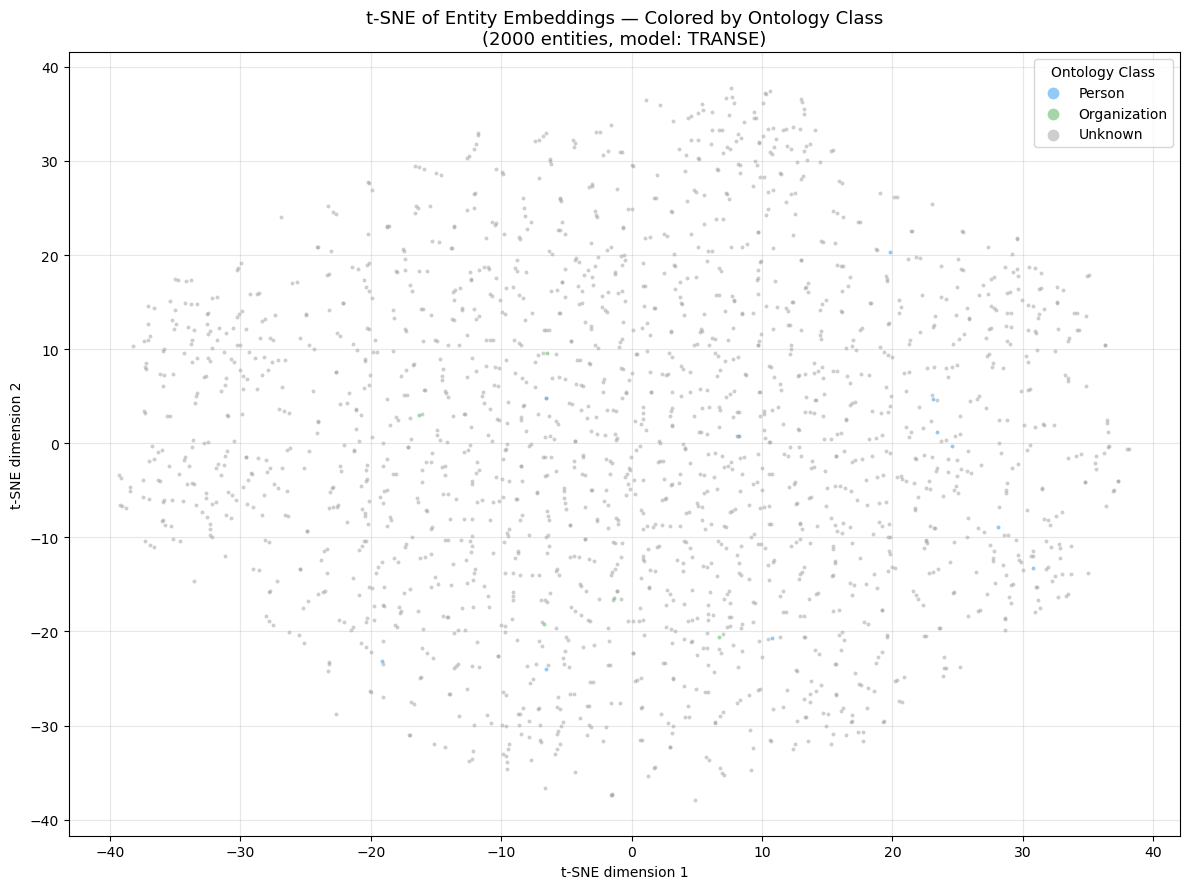

  ✓ Plot saved: output\kge\plots\tsne_entity_embeddings.png

  Class distribution in t-SNE sample:
    Unknown                   : 1,984
    Person                    :    11
    Organization              :     5

  EXERCISE 6.3 — Relation Behavior Analysis

  Symmetric relations (low ||r|| in TransE ≈ r ≈ 0):
  Relation                                         ||r||
  -------------------------------------------------------
  http://ai-kb.local/ontology/relatedTo           0.6758
  http://www.w3.org/2000/01/rdf-schema#subClass   0.8960
  http://www.wikidata.org/prop/direct/P571        0.9080
  http://www.wikidata.org/prop/direct/P21         0.9219
  http://www.wikidata.org/prop/direct/P50         0.9330

  Most anti-correlated relation pairs (potential inverses):
  (cosine similarity close to -1.0 suggests inverse relations)
  No strong inverse pairs detected (cosine < -0.5)
  This may indicate that ComplEx would capture these better

  Composition analysis (r1 + r2 ≈ r3 in TransE):
  E

In [70]:
run_analysis()
